In [49]:
# M24CA1L306 Data Science Lab - Lab Exercise #20
# Student: Abhinav | MAC25MCA-2002 | S3 MCA (2025-27)
# Dataset: <PLACEHOLDER - replace with your wine quality CSV filename>
#          e.g. winequality-red.csv / winequality-white.csv / winequality-combined.csv
#          Separator is typically ";" not ","
# Task: Decision Tree Classifier on Wine Quality Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)


In [61]:

# ─────────────────────────────────────────────
# Load dataset
# ─────────────────────────────────────────────
# PLACEHOLDER: replace filename and separator as needed
df = pd.read_csv("../Datasets/Wine_Quality.csv")
le=LabelEncoder()
df['type']=le.fit_transform(df['type'])
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nQuality distribution:\n", df["quality"].value_counts().sort_index())


Shape: (6497, 13)
Columns: ['type', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Quality distribution:
 quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [62]:

# ─────────────────────────────────────────────
# Feature / Target split
# ─────────────────────────────────────────────
X = df.drop("quality", axis=1).values
y = df["quality"].values
feature_names = df.drop("quality", axis=1).columns.tolist()

# Note: quality is an integer score (3-9). If you want binary classification
# (good vs bad), uncomment the two lines below:
# y = (df["quality"] >= 7).astype(int).values
# class_names = ["Low quality (<7)", "High quality (>=7)"]


In [63]:
# For multiclass keep original labels:
class_names = [str(q) for q in sorted(df["quality"].unique())]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [64]:

# ─────────────────────────────────────────────
# Train Decision Tree - Gini criterion
# ─────────────────────────────────────────────
dt_gini = DecisionTreeClassifier(max_depth=3, random_state=42, criterion="gini")
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)


In [65]:

# ─────────────────────────────────────────────
# Q1: Accuracy on test data
# ─────────────────────────────────────────────
acc_gini = accuracy_score(y_test, y_pred_gini)
print("\n" + "=" * 55)
print("Q1: Accuracy of Decision Tree on Test Data (Gini)")
print("=" * 55)
print(f"Accuracy: {acc_gini:.4f} ({acc_gini*100:.2f}%)")
# Interpretation: The model correctly predicts the quality score for X% of
# wine samples. Wine quality prediction is a challenging multiclass problem
# due to class imbalance (scores 5 and 6 dominate).



Q1: Accuracy of Decision Tree on Test Data (Gini)
Accuracy: 0.5269 (52.69%)



Q2: Confusion Matrix
[[  0   0   2   4   0   0   0]
 [  0   0  18  24   1   0   0]
 [  0   0 225 201   2   0   0]
 [  0   0 110 437  20   0   0]
 [  0   0   9 184  23   0   0]
 [  0   0   1  27  11   0   0]
 [  0   0   0   1   0   0   0]]


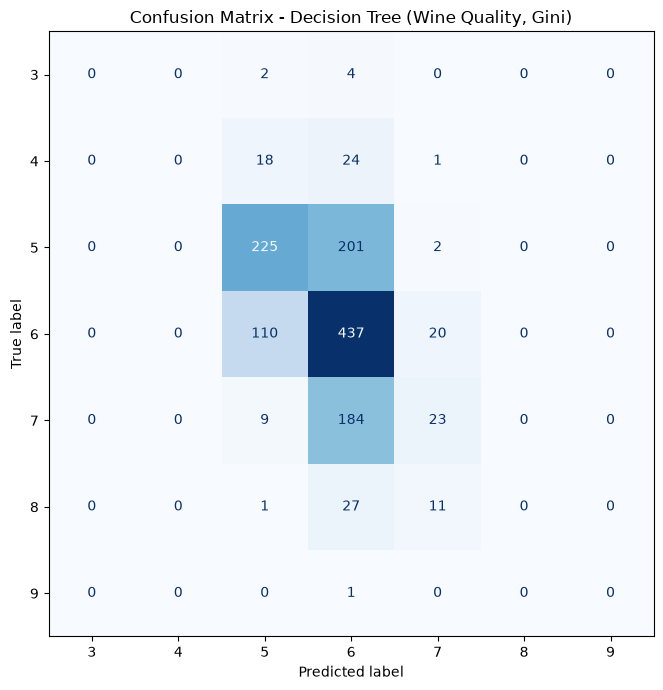

In [66]:

# ─────────────────────────────────────────────
# Q2: Confusion Matrix
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("Q2: Confusion Matrix")
print("=" * 55)

cm = confusion_matrix(y_test, y_pred_gini)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Decision Tree (Wine Quality, Gini)")
plt.tight_layout()
plt.savefig("../Outputs/lab-20_Output/lab20_confusion_matrix.png", dpi=100)
plt.show()

# Interpretation: Diagonal entries are correct predictions. Off-diagonal entries
# are misclassifications - adjacent quality scores (e.g., 5 vs 6) are most
# commonly confused since they share similar physicochemical profiles.


In [67]:

# ─────────────────────────────────────────────
# Q3 & Q4: Precision, Recall, F1 + Classification Report
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("Q3 & Q4: Classification Report (Gini)")
print("=" * 55)
print(classification_report(y_test, y_pred_gini))
# Interpretation:
# Classes 5 and 6 will show higher support and generally better scores.
# Rare classes (3, 4, 8, 9) often have low recall due to few training samples.
# Macro avg treats all classes equally; weighted avg accounts for class frequency.



Q3 & Q4: Classification Report (Gini)
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        43
           5       0.62      0.53      0.57       428
           6       0.50      0.77      0.60       567
           7       0.40      0.11      0.17       216
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1300
   macro avg       0.22      0.20      0.19      1300
weighted avg       0.49      0.53      0.48      1300



/home/user/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


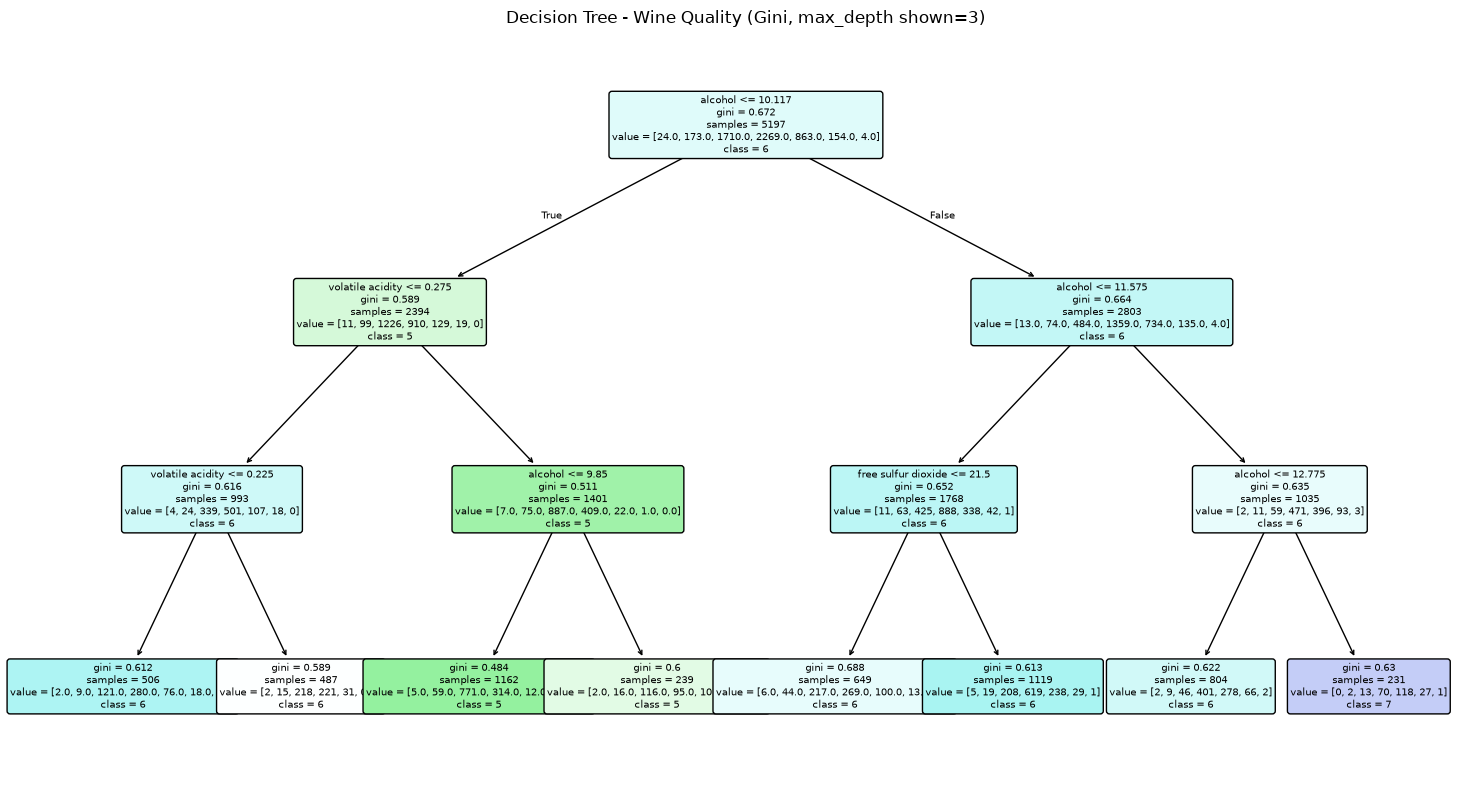


Example decision path:
  Root node typically splits on alcohol or sulphates (high importance)
  e.g. alcohol <= 10.85 -> goes LEFT (lower quality branch)
         sulphates <= 0.645 -> goes LEFT -> predicted class: 5
  A wine with high alcohol and high sulphates reaches a higher quality leaf


In [68]:

# ─────────────────────────────────────────────
# Q5: Visualize Decision Tree + explain one path
# ─────────────────────────────────────────────
plt.figure(figsize=(15, 8))
plot_tree(
    dt_gini,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=7
    # max_depth=3          # show top 3 levels for readability
)
plt.title("Decision Tree - Wine Quality (Gini, max_depth shown=3)")
plt.tight_layout()
plt.savefig("../Outputs/lab-20_Output/lab20_decision_tree_gini.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nExample decision path:")
print("  Root node typically splits on alcohol or sulphates (high importance)")
print("  e.g. alcohol <= 10.85 -> goes LEFT (lower quality branch)")
print("         sulphates <= 0.645 -> goes LEFT -> predicted class: 5")
print("  A wine with high alcohol and high sulphates reaches a higher quality leaf")
# Note: actual path depends on your dataset - inspect the saved tree image



Q6: Gini vs Entropy - Performance Comparison
Gini criterion    -> Accuracy: 0.5269
Entropy criterion -> Accuracy: 0.5392
Difference        : 0.0123


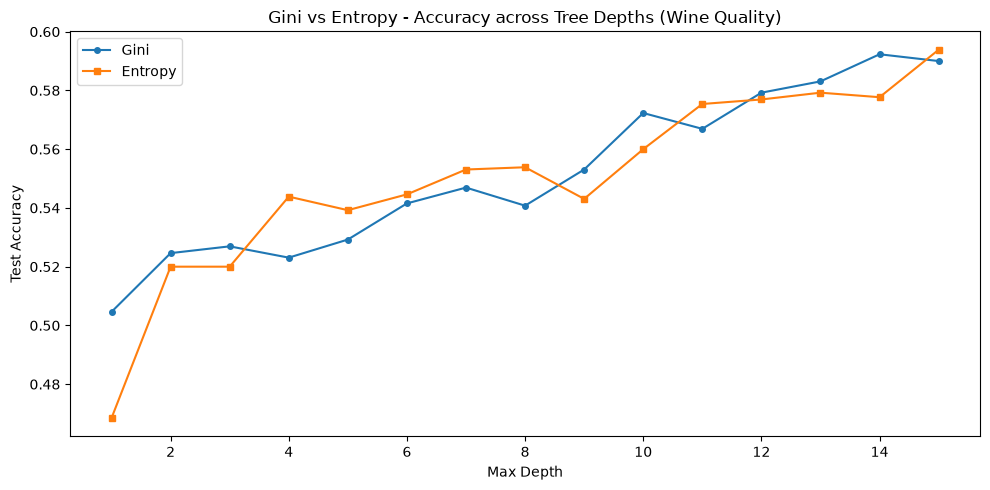


All tasks complete. Plots saved.


In [69]:

# ─────────────────────────────────────────────
# Q6: Gini vs Entropy comparison
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("Q6: Gini vs Entropy - Performance Comparison")
print("=" * 55)

dt_entropy = DecisionTreeClassifier(max_depth=5, random_state=42, criterion="entropy")
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"Gini criterion    -> Accuracy: {acc_gini:.4f}")
print(f"Entropy criterion -> Accuracy: {acc_entropy:.4f}")
print(f"Difference        : {abs(acc_gini - acc_entropy):.4f}")

# Compare across multiple depths
depths = list(range(1, 16))
gini_accs, entropy_accs = [], []
for d in depths:
    g = DecisionTreeClassifier(max_depth=d, criterion="gini",    random_state=42)
    e = DecisionTreeClassifier(max_depth=d, criterion="entropy", random_state=42)
    g.fit(X_train, y_train); gini_accs.append(accuracy_score(y_test, g.predict(X_test)))
    e.fit(X_train, y_train); entropy_accs.append(accuracy_score(y_test, e.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, gini_accs,    label="Gini",    marker="o", markersize=4)
plt.plot(depths, entropy_accs, label="Entropy", marker="s", markersize=4)
plt.xlabel("Max Depth")
plt.ylabel("Test Accuracy")
plt.title("Gini vs Entropy - Accuracy across Tree Depths (Wine Quality)")
plt.legend()
plt.tight_layout()
plt.savefig("../Outputs/lab-20_Output/lab20_gini_vs_entropy.png", dpi=100)
plt.show()

# Interpretation: Gini and entropy typically produce very similar results.
# Gini is computationally cheaper (no log calculation). Entropy can occasionally
# find slightly better splits on imbalanced datasets. The difference rarely
# exceeds 1-2% in practice.

print("\nAll tasks complete. Plots saved.")